# 📊 Cryptocurrency Market Analysis using CoinGecko API

This notebook performs an exploratory data analysis (EDA) of the top N cryptocurrencies (10 by default — customizable) by market capitalization, using real-time data from the CoinGecko public API. The analysis is dynamic and fully reproducible — feel free to execute the cells to fetch the latest data.

**Workflow:**
1. 📥 Fetch Top Coins by Market Cap

2. 📈 Daily Price Trends (Last 30 Days)

3. 🔻 Total 30-Day Percentage Change

# 🔧 Imports & configuration

In [40]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage, TextArea, HPacker, VPacker
import time
from datetime import datetime
from PIL import Image
from io import BytesIO
import numpy as np
import seaborn as sns
from matplotlib.colors import to_rgb

top_n_coins_input = 10 # Number of top coins to fetch, based on market cap, you can change this value
# NOTE: Stablecoins and derivatives are automatically filtered out, so actual displayed count on the graphs may be lower


top_n_coins = min(15, max(1, top_n_coins_input)) # Limit to 15 coins, otherwise it will be too crowded and too slow
LOGOS_DIRECTORY = 'coin_logos'

if not os.path.exists(LOGOS_DIRECTORY):
    os.makedirs(LOGOS_DIRECTORY)

coin_logos = {}
list_for_dataframe = []

sns.set_theme()

# 📥 Fetching Top Coins by Market Cap

We begin by retrieving the top **N** cryptocurrencies by market capitalization. For each coin, we display:

- Name

- Symbol

- Current price (USD)

- Market cap (USD)

This gives a quick overview of the most prominent assets in the current market.

In [ ]:
url = 'https://api.coingecko.com/api/v3/coins/markets' # CoinGecko public API, no API key required but rate-limited so higher amount of requests will take longer
params = {
    'vs_currency': 'usd',
    'order': 'market_cap_desc',
    'per_page': top_n_coins,
    'page': 1,
}

todays_date = datetime.today().strftime('%Y-%m-%d') # Get today's date in YYYY-MM-DD format
response = requests.get(url, params=params)
top_coins = response.json()

print(f"Top {top_n_coins} cryptocurrencies by market cap as of {todays_date}:\n")

for i, coin in enumerate(top_coins):
    print(f"{i + 1}: {coin['name']} ({coin['symbol'].upper()})")
    print(f"   Market Cap: ${coin['market_cap']:,}")
    print(f"   Current Price: ${coin['current_price']:,}")
    print()

Top 10 cryptocurrencies by market cap as of 2026-01-27:

1: Bitcoin (BTC)
   Market Cap: $1,762,971,376,602
   Current Price: $88,235

2: Ethereum (ETH)
   Market Cap: $353,093,725,672
   Current Price: $2,925.59

3: Tether (USDT)
   Market Cap: $186,310,129,904
   Current Price: $0.998796

4: BNB (BNB)
   Market Cap: $120,311,716,341
   Current Price: $882.31

5: XRP (XRP)
   Market Cap: $115,349,776,485
   Current Price: $1.9

6: USDC (USDC)
   Market Cap: $71,949,764,736
   Current Price: $0.99961

7: Solana (SOL)
   Market Cap: $70,242,448,298
   Current Price: $124.07

8: TRON (TRX)
   Market Cap: $27,984,020,261
   Current Price: $0.295314

9: Lido Staked Ether (STETH)
   Market Cap: $27,561,518,476
   Current Price: $2,923.99

10: Dogecoin (DOGE)
   Market Cap: $20,559,881,479
   Current Price: $0.122027



# 📊 30-Day Price & Volatility Analysis

Track daily price movements alongside volatility patterns for each cryptocurrency:

- Daily prices plotted at each data point
- Starting price baseline for performance comparison  
- Volatility highlights showing % change on days exceeding the threshold
- Brand-matched colors and logos

📌 Synchronized timeline for cross-coin comparisons.

💡 **Tip:** Adjust the `volatility_threshold` variable in the code to change sensitivity (default: 2%).

Error fetching data for USDC (USDC): 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/usd-coin/market_chart?vs_currency=usd&days=30&interval=daily
Retrying in 1 minute... (attempt 1/3)
Error fetching data for TRON (TRX): 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/tron/market_chart?vs_currency=usd&days=30&interval=daily
Retrying in 1 minute... (attempt 1/3)
Stable coin/derivative removed: Tether (USDT)
Stable coin/derivative removed: USDC (USDC)
Stable coin/derivative removed: Lido Staked Ether (STETH)
Adjusting the color of XRP (XRP) to dark gray so it contrasts better with the background.


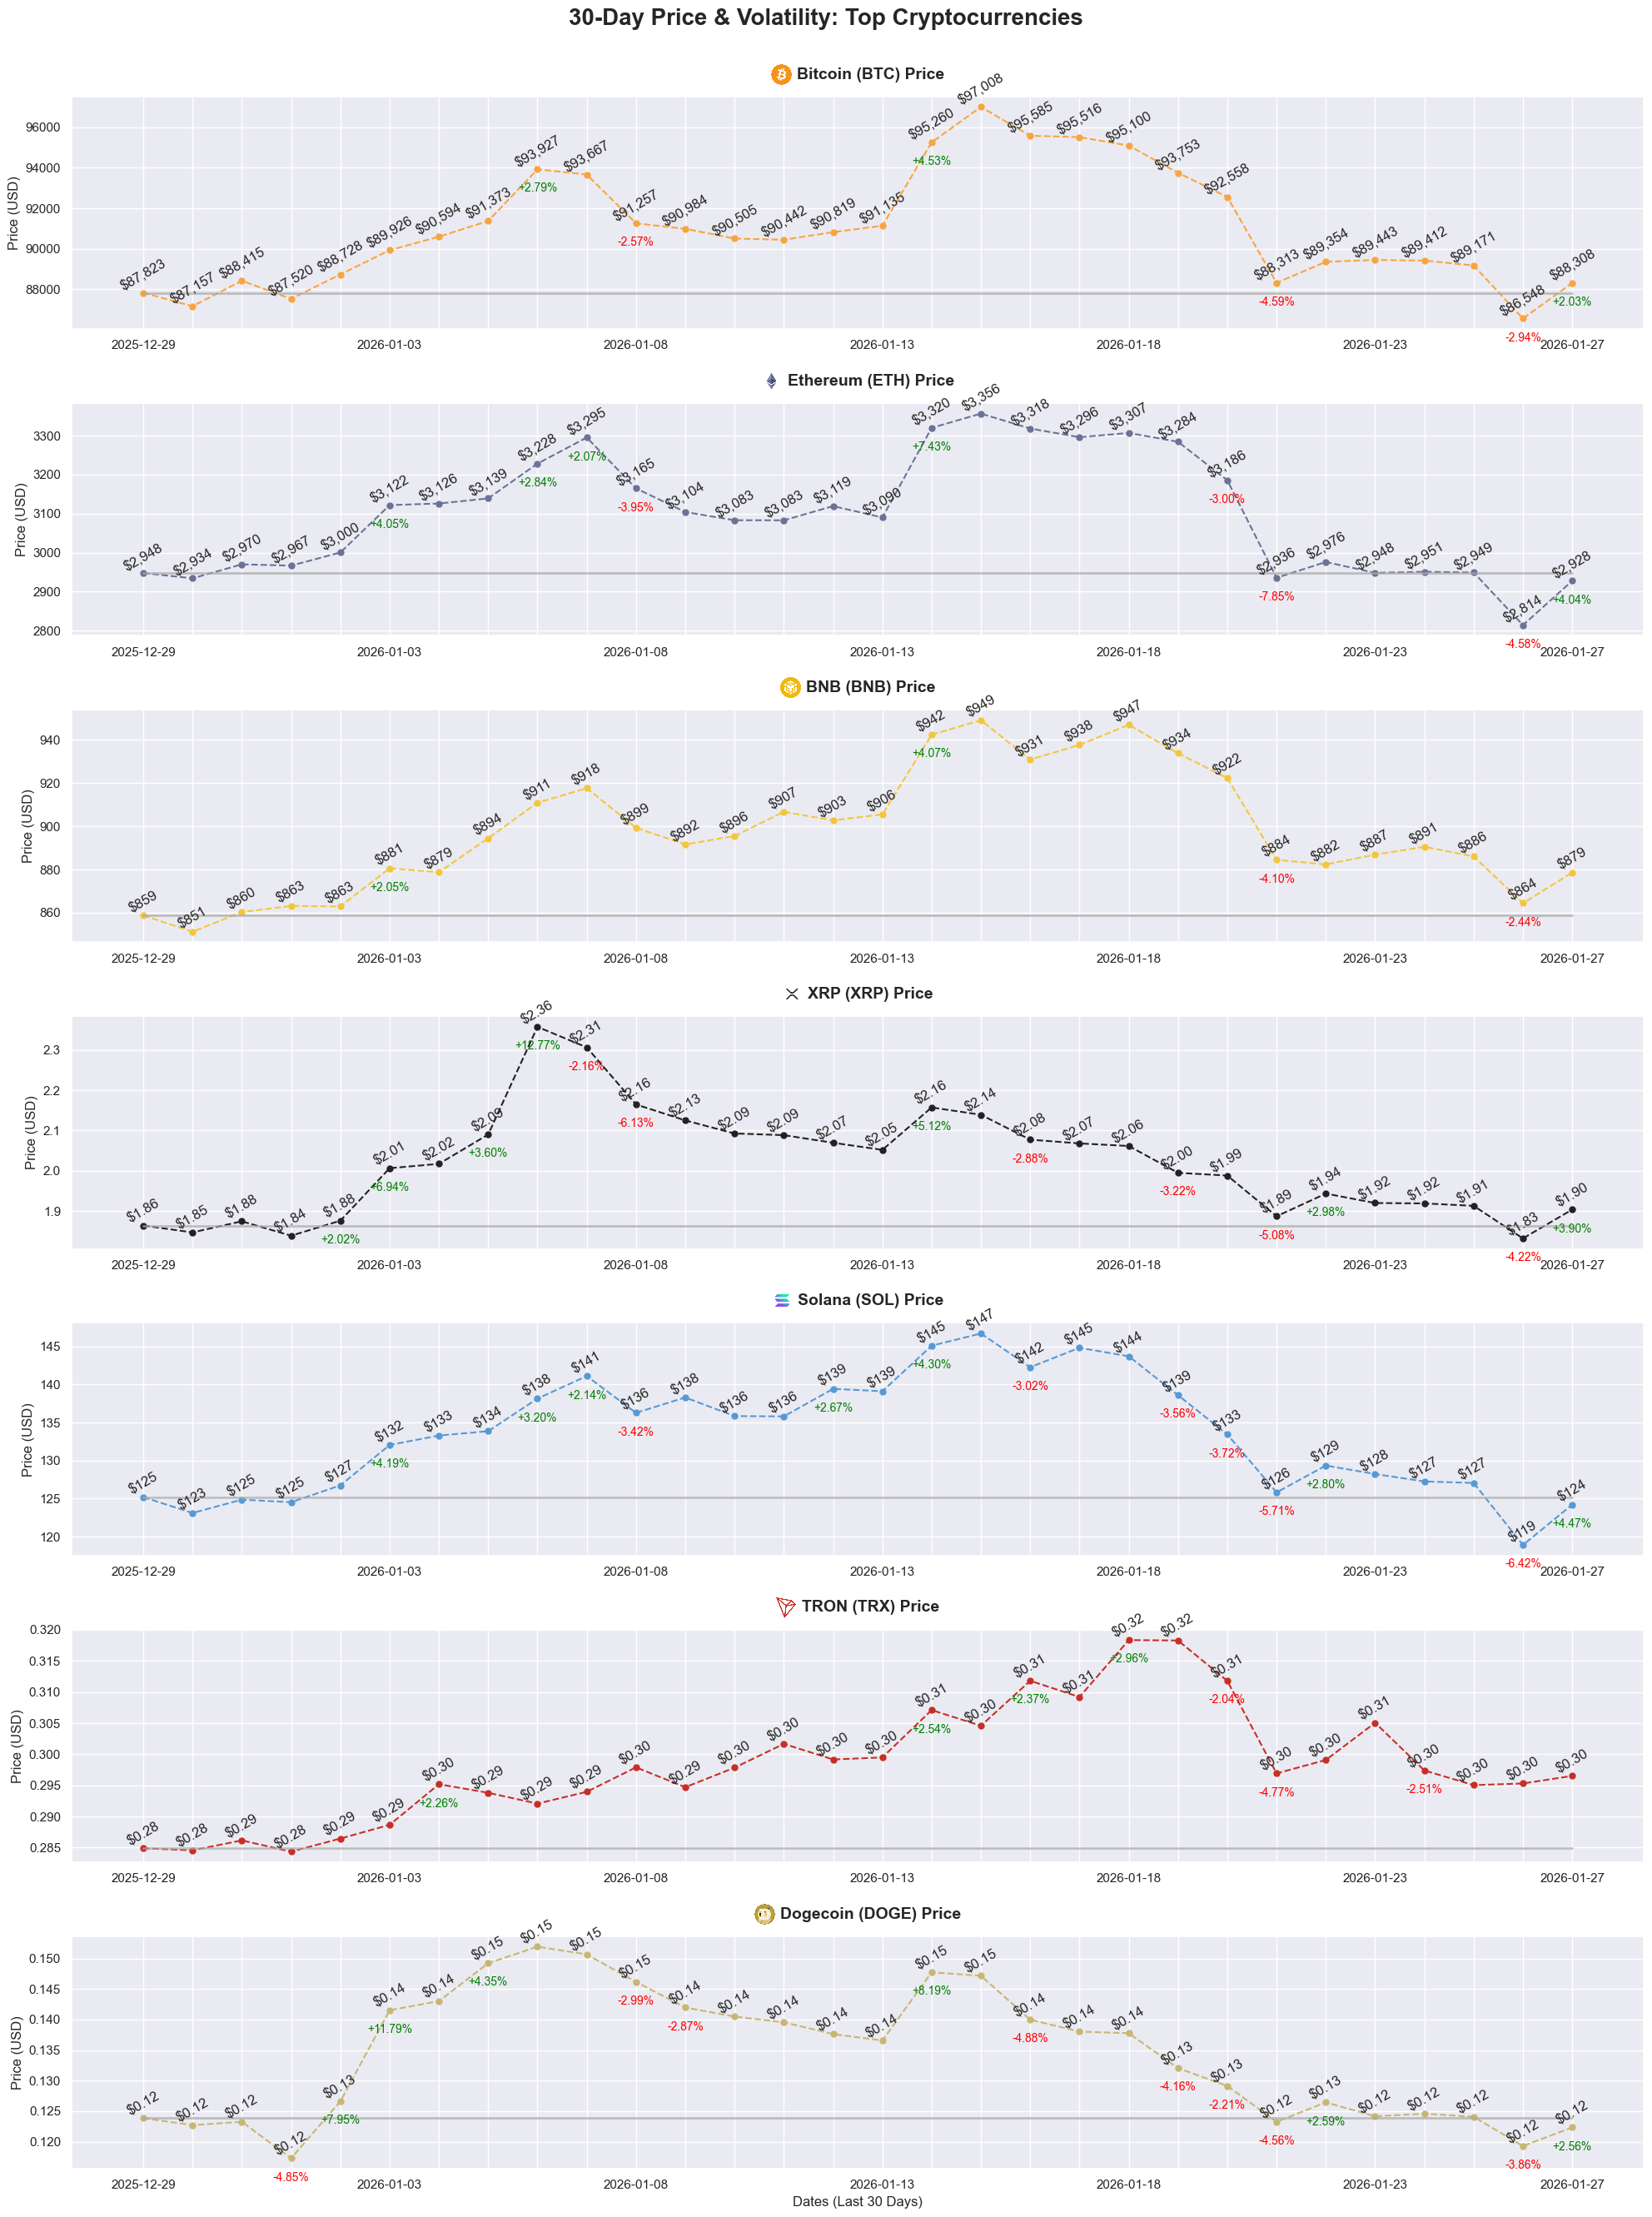

In [42]:
def get_dominant_color(image_path):
    img = Image.open(image_path).convert('RGBA')
    img = img.resize((50, 50))  # Resize to reduce noise
    img_np = np.array(img)
    
    # Remove fully transparent pixels
    pixels = img_np.reshape(-1, 4)
    pixels = pixels[pixels[:, 3] > 0]  # Keep only non-transparent pixels

    rgb_pixels = pixels[:, :3]
    avg_color = tuple(np.mean(rgb_pixels, axis=0).astype(int))
    
    return tuple(float(c)/255 for c in avg_color) # Convert to 0-1 range and return as a python tuple, numpy array will cause issues if it's saved to a csv and it's not needed.

def get_logo_return_dominant_color(coin):
    logo_path = os.path.join(LOGOS_DIRECTORY, f"{coin['id']}.png")
    
    if not os.path.exists(logo_path):
        try:
            response = requests.get(coin['image'], timeout=10)
            response.raise_for_status()

            # Open image with PIL (supports many formats: JPG, WEBP, etc.)
            img = Image.open(BytesIO(response.content)).convert('RGBA')  # Convert to RGBA for PNG
            img.save(logo_path, format='PNG')
        
        except Exception as e:
            print(f"Failed to fetch or convert logo for {coin['name']}: {e}")
            return

    try:
        logo_img = mpimg.imread(logo_path)
        coin_logos[coin['id']] = logo_img
        dominant_color = get_dominant_color(logo_path)
        return dominant_color
    except Exception as e:
        print(f"Error reading saved image for {coin['name']}: {e}")
        return 'blue'

def luminance(r, g, b):
    # Convert to luminance
    a = [v/12.92 if v <= 0.03928 else ((v+0.055)/1.055)**2.4 for v in (r, g, b)]
    return 0.2126*a[0] + 0.7152*a[1] + 0.0722*a[2]

def contrast_ratio(rgb1, rgb2):
    L1 = luminance(*rgb1)
    L2 = luminance(*rgb2)
    return (max(L1, L2) + 0.05) / (min(L1, L2) + 0.05)

def ensure_contrast(color_hex, name, background_hex='#e5e6fa', threshold=2):
    rgb1 = to_rgb(color_hex)
    rgb2 = to_rgb(background_hex)
    ratio = contrast_ratio(rgb1, rgb2)
    
    if ratio < threshold:
        print(f"Adjusting the color of {name} to dark gray so it contrasts better with the background.")
        return '#222222'  # Fallback to dark gray, might experiment with this
    return color_hex


for coin in top_coins:
    retries = 0
    
    dominant_color = get_logo_return_dominant_color(coin) # Fetch and save the logo
    
    params = {
        'vs_currency': 'usd',
        'days': '30',
        'interval': 'daily',
    }
    url = f"https://api.coingecko.com/api/v3/coins/{coin['id']}/market_chart"
    
    while retries < 3:
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()

            if 'prices' not in data:
                raise ValueError(f"No 'prices' in response: {data}")

            seen_dates = set()

            for day in data['prices']:
                timestamp, price = day
                date_str = datetime.fromtimestamp(timestamp / 1000).strftime("%Y-%m-%d")
                if date_str not in seen_dates:
                    list_for_dataframe.append({
                        'name': f"{coin['name']} ({coin['symbol'].upper()})",
                        'id': coin['id'],
                        'date': date_str,
                        'price': price,
                        'dominant_color': dominant_color,
                    })
                    seen_dates.add(date_str)
            break
        except Exception as e:
            retries += 1
            print(f"Error fetching data for {coin['name']} ({coin['symbol'].upper()}): {e}")
            if retries < 3:
                print(f"Retrying in 1 minute... (attempt {retries}/3)")
                time.sleep(60) # Wait for 1 minute because the API is rate-limited per minute
            else:
                print(f"Failed to fetch data for {coin['name']} ({coin['symbol'].upper()}) after 3 attempts.")
    
df = pd.DataFrame(list_for_dataframe)

grouped = df.groupby('name')['price']
mean_prices = grouped.mean()
std_prices = grouped.std()

# Calculate coefficient of variation (CV)
cv = std_prices / mean_prices

stablecoins = cv[cv < 0.01].index
derivatives = ['Lido Staked Ether (STETH)'] # Add the derivatives manually since CV won't catch them
stablecoins_and_derivatives = stablecoins.tolist() + derivatives

stablecoins_df = df[df['name'].isin(stablecoins_and_derivatives)] # May use later
df = df[~df['name'].isin(stablecoins_and_derivatives)]

volatility_threshold = 2 # % Threshold for daily movements to be recorded as volatile
volatility_dict = {}
largest_single_drop = [[None, 0]]
largest_single_increase = [[None, 0]]

for name in stablecoins_and_derivatives:
        print(f"Stable coin/derivative removed: {name}")
    
unique_names = df['name'].unique()
fig, axes = plt.subplots(len(unique_names), 1, figsize=(20, 4 * len(unique_names)), sharex=True)

if len(unique_names) == 1:
    axes = [axes]

for ax, name in zip(axes, unique_names):
    volatility_amount = 0
    group = df[df['name'] == name]
    group = group.sort_values('date')
    group['pct_change'] = group['price'].pct_change() * 100
    
    coin_dominant_color = group['dominant_color'].iloc[0]
    coin_id = group['id'].iloc[0]
    
    line_color = ensure_contrast(coin_dominant_color, name, threshold=1.3)

    ax.plot(group['date'], group['price'], 'o--', label=name, color=line_color, linewidth=1.5, markersize=5)

    start_price = group['price'].iloc[0]
    start_date = group['date'].iloc[0]
    end_date = group['date'].iloc[-1]
    ax.plot([start_date, end_date], [start_price, start_price], 
            color='darkgray', linestyle='-', linewidth=2, alpha=0.7, 
            label=f'Start Price: ${start_price:,.2f}')

    for x, y, pct in zip(group['date'], group['price'], group['pct_change']):
        if y > 50:
            price_label = f"${y:,.0f}"
        else:
            price_label = f"${y:,.2f}"
        ax.text(x, y, price_label, fontsize=12, ha='center', va='bottom', rotation=30)

        if not pd.isna(pct):
            pct_label = f"{pct:+.2f}%"
            text_color = 'green' if pct > 0 else 'red' if pct < 0 else 'gray'
            if pct >= volatility_threshold or pct <= -volatility_threshold:
                ax.text(x, y, f"\n{pct_label}", fontsize=10, color=text_color, ha='center', va='top', rotation=0)
                volatility_amount += 1
                
            if pct > largest_single_increase[0][1]:
                largest_single_increase = [[name, pct]]
            elif pct == largest_single_increase[0][1]:
                largest_single_increase.append([[name, pct]])
                
            if pct < largest_single_drop[0][1]:
                largest_single_drop = [[name, pct]]
            elif pct == largest_single_drop[0][1]:
                largest_single_drop.append([[name, pct]])    
                
        
    title_text = f"{name} Price"
    volatility_dict[name] = volatility_amount
    
    if coin_id in coin_logos:
        try:
            logo_img = coin_logos[coin_id]
            imagebox = OffsetImage(logo_img, zoom=0.07)
            textbox = TextArea(title_text, textprops=dict(fontsize=14, weight='bold'))

            vbox = HPacker(children=[imagebox, textbox], align='center', pad=0, sep=5)

            ab = AnnotationBbox(
                vbox,
                (0.5, 1.05),
                xycoords='axes fraction',
                frameon=False,
                box_alignment=(0.5, 0)
            )
            ax.add_artist(ab)
        except Exception as e:
            print(f"Error adding logo/title for {name}: {e}. Using text title.")
            ax.set_title(title_text, fontsize=14, weight='bold', pad=20)
    else:
        print(f"Logo not found for {name}. Using text title.")
        ax.set_title(title_text, fontsize=14, weight='bold', pad=20)
    
    # Show every 5th date label to reduce crowding
    ax.tick_params(labelbottom=True, rotation=0)
    date_labels = ax.get_xticklabels()
    for i, label in enumerate(date_labels):
        if i % 5 != 0 and i != len(date_labels) - 1:
            label.set_visible(False)
    
    ax.set_ylabel('Price (USD)')
    ax.grid(True)

plt.suptitle('30-Day Price & Volatility: Top Cryptocurrencies', fontsize=20, weight='bold')
plt.xlabel('Dates (Last 30 Days)')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.show()

In [43]:
volatility_series = pd.Series(volatility_dict).sort_values(ascending=False)

max_volatility = volatility_series.max()
min_volatility = volatility_series.min()

most_volatile_coins = volatility_series[volatility_series == max_volatility].index.tolist()
most_stable_coins = volatility_series[volatility_series == min_volatility].index.tolist()

def plural_days(count):
    return f"{int(count)} day" if count == 1 else f"{int(count)} days"

if len(most_volatile_coins) == 1:
    volatile_text = f"{most_volatile_coins[0]} ({plural_days(max_volatility)} with ±{volatility_threshold}%+ swings)"
else:
    coins_list = ', '.join(most_volatile_coins)
    volatile_text = f"{coins_list} (tied at {plural_days(max_volatility)} with ±{volatility_threshold}%+ swings)"

if len(most_stable_coins) == 1:
    stable_text = f"{most_stable_coins[0]} ({plural_days(min_volatility)} volatile)"
else:
    coins_list = ', '.join(most_stable_coins)
    stable_text = f"{coins_list} (tied at {plural_days(min_volatility)} volatile)"

print('📊 Volatility Analysis:')
print('')
print(f"• Most volatile: {volatile_text}")
print(f"• Most stable: {stable_text}")
print('')
print(f"• Largest single drop: {largest_single_drop[0][0]} ({largest_single_drop[0][1]:.2f}%)")
print(f"• Largest single increase: {largest_single_increase[0][0]} (+{largest_single_increase[0][1]:.2f}%)")

📊 Volatility Analysis:

• Most volatile: Dogecoin (DOGE) (14 days with ±2%+ swings)
• Most stable: BNB (BNB) (4 days volatile)

• Largest single drop: Ethereum (ETH) (-7.85%)
• Largest single increase: XRP (XRP) (+12.77%)


# 🔻 3. Total 30-Day Percentage Change
This bar chart visualizes the total percentage change in price over the last 30 days for each coin, in a descending order. Each bar is styled using the coin’s dominant logo color (lightened for better readability), and is annotated with:

- Starting price (30 days ago)

- Ending price (today)

- Percentage change

- Coin logo, centered in the middle of the bar

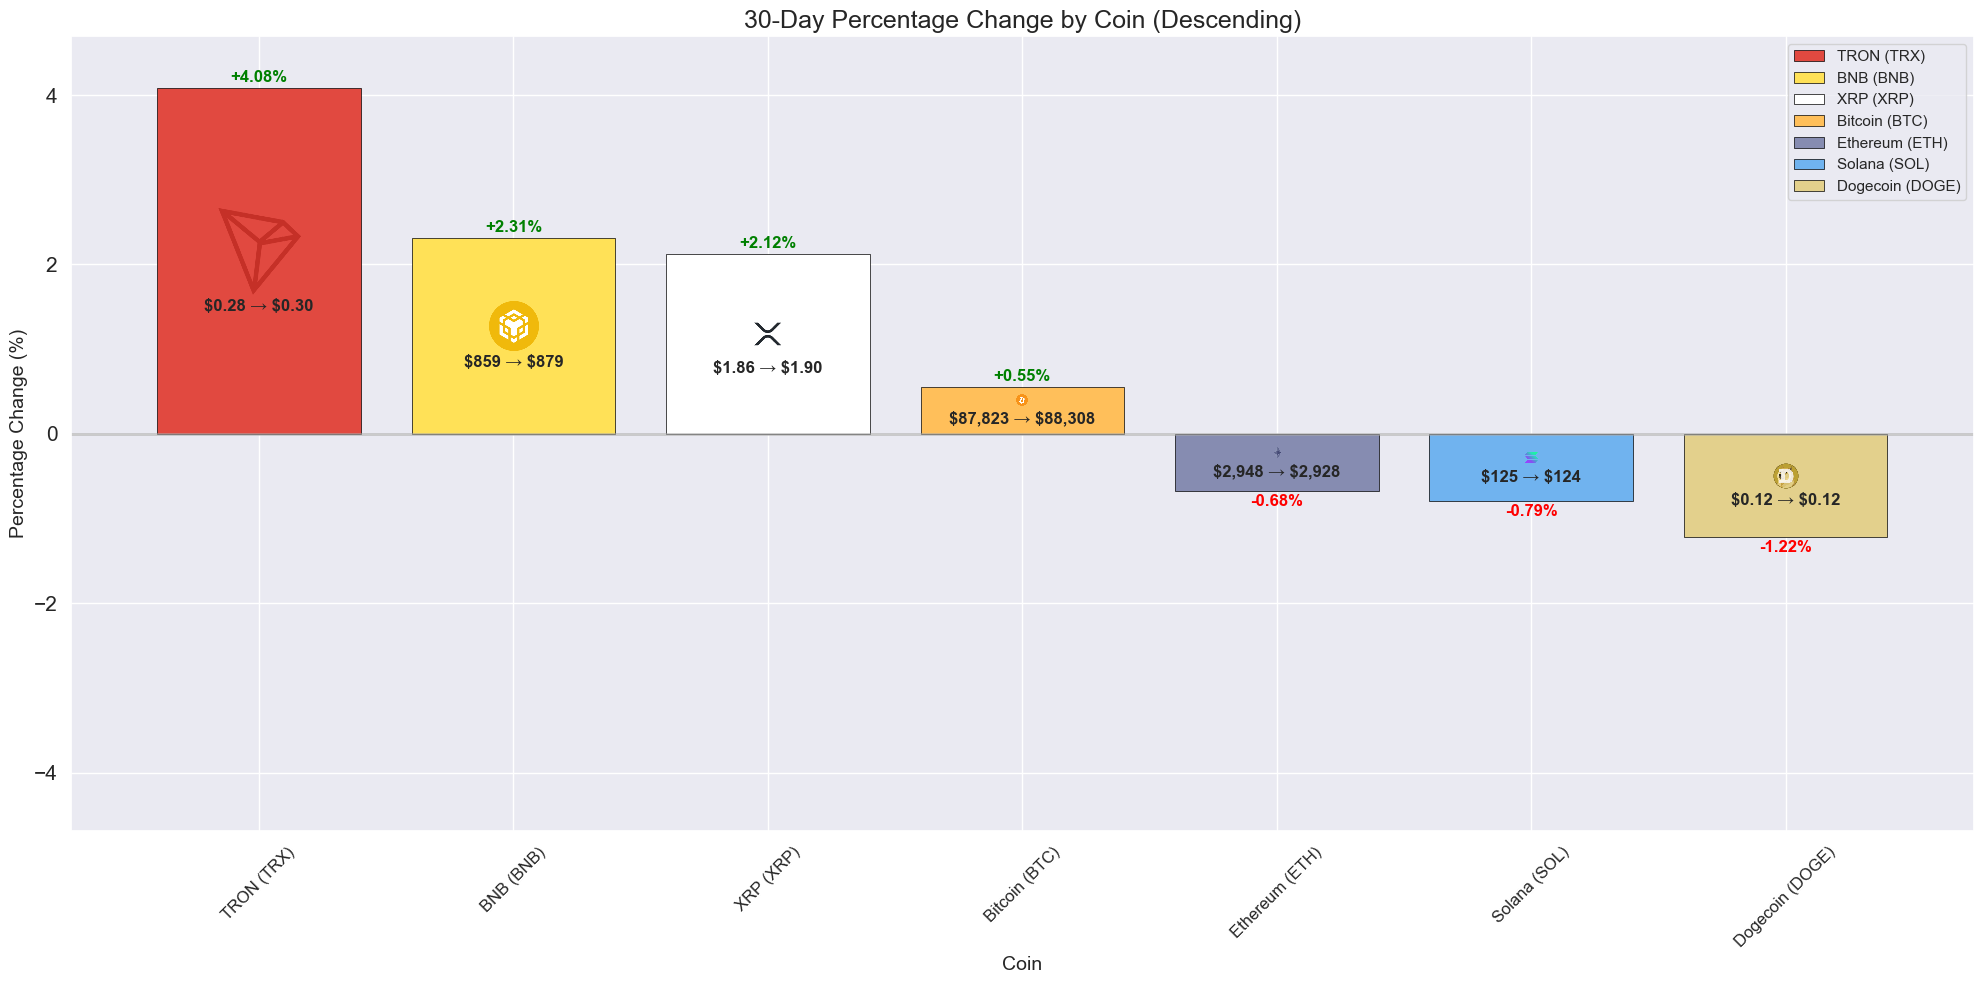

In [44]:
first_prices = df.sort_values('date').groupby('name').first().reset_index()
last_prices = df.sort_values('date').groupby('name').last().reset_index()

# Merge and calculate percentage change
merged = pd.merge(first_prices[['name', 'price']], last_prices[['name', 'price']], on='name', suffixes=('_start', '_end'))
merged['pct_change'] = ((merged['price_end'] - merged['price_start']) / merged['price_start']) * 100
merged['id'] = df.groupby('name')['id'].first().values
merged['dominant_color'] = df.groupby('name')['dominant_color'].first().values

merged = merged.sort_values('pct_change', ascending=False).set_index('name')
max_abs_pct = max(abs(merged['pct_change']))
y_range = max_abs_pct * 1.15
offset = y_range * 0.045

colors = [merged['dominant_color'].iloc[i] for i in range(len(merged))]
lightened_colors = [tuple(min(1, c + 0.1) for c in color) for color in colors] # Lighten the background colors for better contrast with logos

plt.figure(figsize=(20, 10))
plt.bar(merged.index, merged['pct_change'], color=lightened_colors, edgecolor='black', linewidth=0.5, label=merged.index)

def calculate_logo_size(name):
    return abs(merged['pct_change'][name] / max_abs_pct)

for i, (x, pct) in enumerate(zip(merged.index, merged['pct_change'])):
    percent_label = f"{pct:+.2f}%"
    text_color = 'green' if pct > 0 else 'red' if pct < 0 else 'gray'
    coin_id = merged['id'].iloc[i]
    
    if pct < 0:
        plt.text(x, pct - offset, percent_label, fontsize=12, ha='center', va='bottom', color=text_color, weight='bold')
    else:
        plt.text(x, pct + offset, percent_label, fontsize=12, ha='center', va='top', color=text_color, weight='bold')

    price_start = merged.loc[x, 'price_start']
    price_end = merged.loc[x, 'price_end']
    if price_start > 50 and price_end > 50:
        price_change_label = rf"\${price_start:,.0f} → \${price_end:,.0f}"
    else:
        price_change_label = rf"\${price_start:,.2f} → \${price_end:,.2f}"
     
    if coin_id in coin_logos:
        logo_size_multiplier = calculate_logo_size(x)
        if logo_size_multiplier > 0.1:
            try:
                imagebox = OffsetImage(coin_logos[coin_id], zoom=0.25*logo_size_multiplier)  # Adjust size of logos
                textbox = TextArea(price_change_label, textprops=dict(fontsize=12, weight='bold'))
                
                vbox = VPacker(children=[imagebox, textbox], align='center', pad=0, sep=3)
                
                ab = AnnotationBbox(vbox, (i, pct/2), frameon=False)
                plt.gca().add_artist(ab)
            except FileNotFoundError:
                pass

plt.ylim(-y_range, y_range)
plt.axhline(y=0, color='darkgray', linewidth=2, alpha=0.6)
plt.title('30-Day Percentage Change by Coin (Descending)', fontsize=18)
plt.ylabel('Percentage Change (%)', fontsize=14)
plt.xlabel('Coin', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print('📈 30-Day Returns:')
print()

max_coin = merged['pct_change'].idxmax()
max_val = merged['pct_change'].iloc[0]

min_coin = merged['pct_change'].idxmin()
min_val = merged['pct_change'].iloc[-1]

pct_spread = max_val - min_val

all_positive = min_val > 0
all_negative = max_val < 0

if all_positive:
    print(f"✅ All top {top_n_coins} cryptocurrencies increased in price!")
    print(f"• Best performer: {max_coin} ({max_val:+.2f}%)")
    print(f"• Weakest performer: {min_coin} ({min_val:+.2f}%)")
elif all_negative:
    print(f"❌ All top {top_n_coins} cryptocurrencies decreased in price!")
    print(f"• Smallest loss: {max_coin} ({max_val:+.2f}%)")
    print(f"• Biggest loss: {min_coin} ({min_val:+.2f}%)")
else:
    print(f"• Best performer: {max_coin} ({max_val:+.2f}%)")
    print(f"• Worst performer: {min_coin} ({min_val:+.2f}%)")

print(f"• Performance spread: {pct_spread:.2f} percentage points")
print()

📈 30-Day Returns:

• Best performer: TRON (TRX) (+4.08%)
• Worst performer: Dogecoin (DOGE) (-1.22%)
• Performance spread: 5.30 percentage points

